## Inteligență Artificială  Tema 1 - 2025: Sokoban

Responsabili:
- Andrei Olaru
- Cătălin Chiru
- Andrei Dugăeșescu
- Mihai Nan
- Vlad Matei Drăghici
- Alexandru Baciu
- Bogdan-Andrei Sprîncenatu

# Imports and Setup

In [37]:
import os
import time
import matplotlib.pyplot as plt
from typing import Dict
from sokoban.map import Map
from search_methods.lrta_star import LRTAStar
from search_methods.simmulated_annealing import SimulatedAnnealing

# Test Map

In [38]:
test_maps = [
    'tests/easy_map1.yaml',
    'tests/easy_map2.yaml',
    'tests/medium_map1.yaml',
    'tests/medium_map2.yaml',
    'tests/hard_map1.yaml',
    'tests/hard_map2.yaml',
    'tests/large_map1.yaml',
    'tests/large_map2.yaml',
    'tests/super_hard_map1.yaml'
]

results = []

# Run and Visualize LRTA* and Simulated Annealing

In [39]:
def solve_and_visualize(solver, map_file: str, algorithm_name: str, quiet: bool = False) -> Dict:
    """Run solver on a map and collect metrics"""
    # Load the map
    initial_state = Map.from_yaml(map_file)
    # Time the solution
    start_time = time.time()
    solution = solver.solve(initial_state)
    solve_time = time.time() - start_time

    results = {
        'solved': solution is not None,
        'time': solve_time,
        'moves': len(solution) if solution else 0,
        'states_explored': getattr(solver, 'states_explored', 0),
        'pull_moves': sum(1 for move in solution if move >= 4) if solution else 0
    }

    if not quiet:
        if solution is None:
            print("No solution found!")
        else:
            print(f"Solution found with {results['moves']} moves")
            print(f"States explored: {results['states_explored']}")
            print(f"Pull moves used: {results['pull_moves']}")
            print(f"Time taken: {results['time']:.2f} seconds")

            # Save visualization in algorithm-specific subdirectory
            map_name = os.path.basename(map_file).replace(".yaml", "")
            output_dir = os.path.join(
                os.path.dirname(map_file),
                'solutions',
                algorithm_name.replace(' ', '_').lower(),
                map_name
            )
            os.makedirs(output_dir, exist_ok=True)

            state = initial_state.copy()
            #state.save_map(output_dir, f'{map_name}_initial_state')
            print(f"Initial state for {map_name} ")
            state.plot_map()

            for move in solution:
                state.apply_move(move)
            print(f"Solved state for {map_name} ")
            state.plot_map()
    return results




# Plot Comparisons for Runtime, States Explored and Pull Moves

In [40]:
def plot_comparisons(results):
    # Separate results by algorithm
    lrta_results = [r for r in results if r['algorithm'] == 'LRTA*']
    sa_results = [r for r in results if r['algorithm'] == 'Simulated Annealing']

    # Extract relevant data
    maps = [r['map'] for r in lrta_results]

    lrta_times = [r['time'] for r in lrta_results]
    sa_times = [r['time'] for r in sa_results]

    lrta_states = [r['states_explored'] for r in lrta_results]
    sa_states = [r['states_explored'] for r in sa_results]

    lrta_pull_moves = [r['pull_moves'] for r in lrta_results]
    sa_pull_moves = [r['pull_moves'] for r in sa_results]

    # Plot Runtime Comparison
    plt.figure(figsize=(10, 5))
    plt.bar(maps, lrta_times, label="LRTA*", alpha=0.6, color='green')
    plt.bar(maps, sa_times, label="Simulated Annealing", alpha=0.6, color='red')
    plt.xlabel('Map')
    plt.ylabel('Time (seconds)')
    plt.title('Runtime Comparison')
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot States Explored Comparison
    plt.figure(figsize=(10, 5))
    plt.bar(maps, lrta_states, label="LRTA*", alpha=0.6, color='green')
    plt.bar(maps, sa_states, label="Simulated Annealing", alpha=0.6, color='blue')
    plt.xlabel('Map')
    plt.ylabel('States Explored')
    plt.title('States Explored Comparison')
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot Pull Moves Comparison
    plt.figure(figsize=(10, 5))
    plt.bar(maps, lrta_pull_moves, label="LRTA*", alpha=0.6, color='green')
    plt.bar(maps, sa_pull_moves, label="Simulated Annealing", alpha=0.6, color='blue')
    plt.xlabel('Map')
    plt.ylabel('Pull Moves')
    plt.title('Pull Moves Comparison')
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

# run and visualize LRTA* and Simulated Annealing

# Test LRTA*


=== Testing LRTA* Algorithm ===

Testing easy_map1.yaml...
Solution found with 165 moves
States explored: 3863
Pull moves used: 45
Time taken: 0.37 seconds
Initial state for easy_map1 


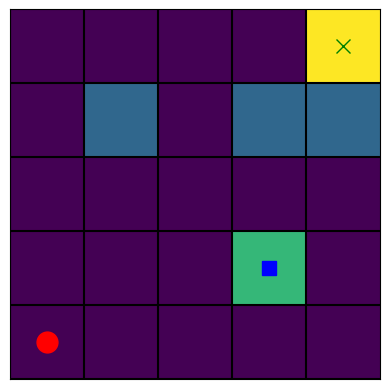

Solved state for easy_map1 


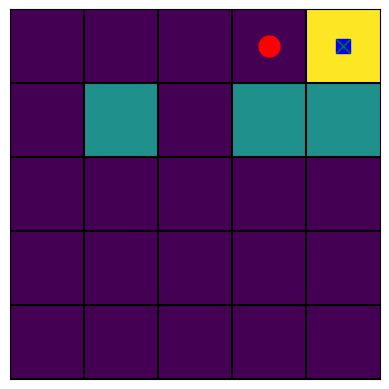


Testing easy_map2.yaml...
Solution found with 15 moves
States explored: 15
Pull moves used: 4
Time taken: 0.01 seconds
Initial state for easy_map2 


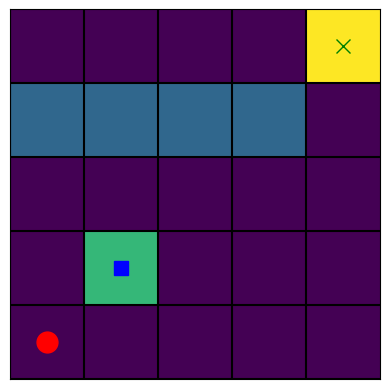

Solved state for easy_map2 


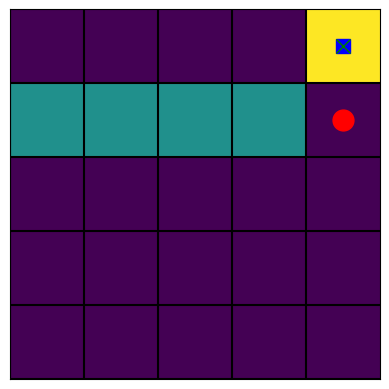


Testing medium_map1.yaml...
Solution found with 29 moves
States explored: 29
Pull moves used: 11
Time taken: 0.01 seconds
Initial state for medium_map1 


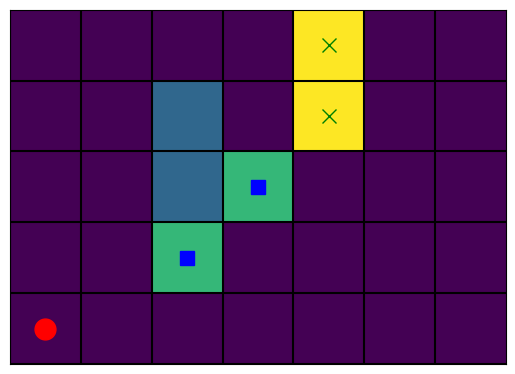

Solved state for medium_map1 


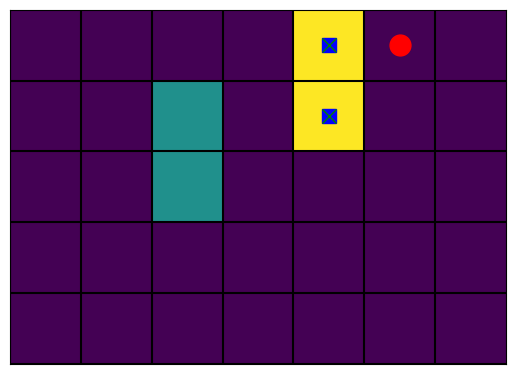


Testing medium_map2.yaml...
Solution found with 1870 moves
States explored: 5545
Pull moves used: 525
Time taken: 1.31 seconds
Initial state for medium_map2 


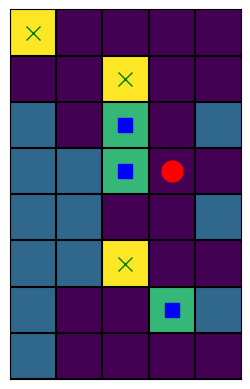

Solved state for medium_map2 


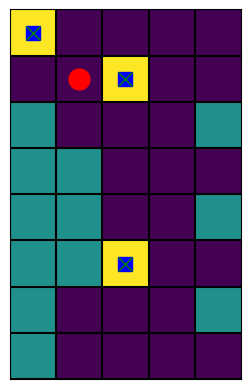


Testing hard_map1.yaml...
Solution found with 1888 moves
States explored: 4938
Pull moves used: 673
Time taken: 2.37 seconds
Initial state for hard_map1 


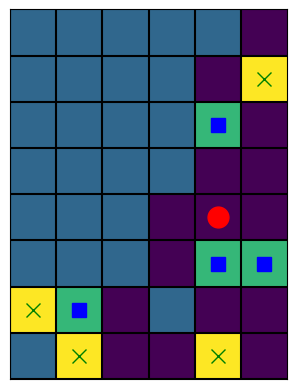

Solved state for hard_map1 


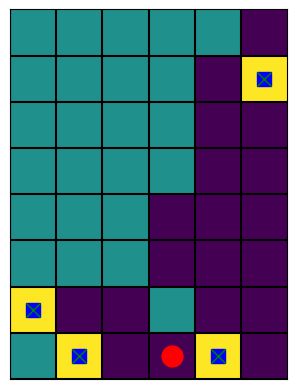


Testing hard_map2.yaml...
Solution found with 1540 moves
States explored: 4803
Pull moves used: 422
Time taken: 1.21 seconds
Initial state for hard_map2 


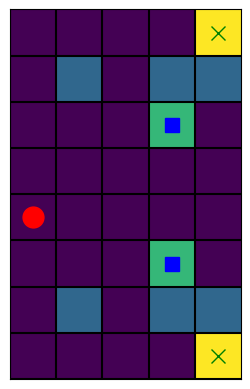

Solved state for hard_map2 


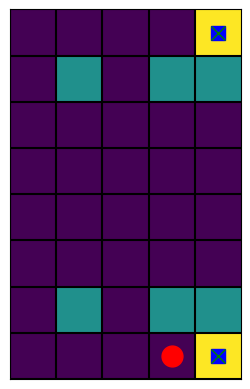


Testing large_map1.yaml...
Solution found with 309 moves
States explored: 531
Pull moves used: 87
Time taken: 0.21 seconds
Initial state for large_map1 


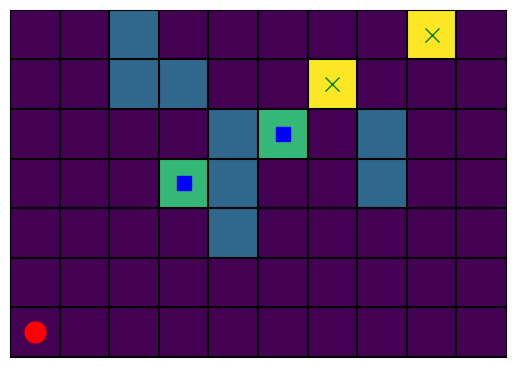

Solved state for large_map1 


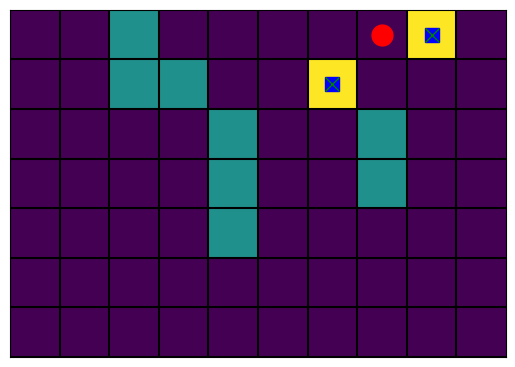


Testing large_map2.yaml...
Solution found with 894 moves
States explored: 2263
Pull moves used: 227
Time taken: 0.90 seconds
Initial state for large_map2 


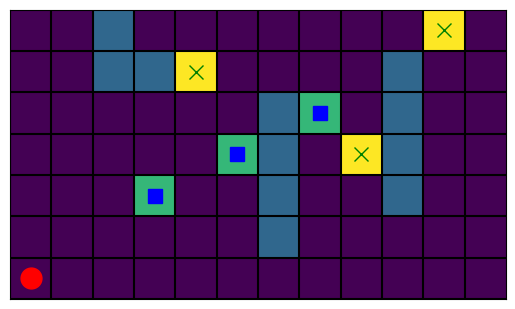

Solved state for large_map2 


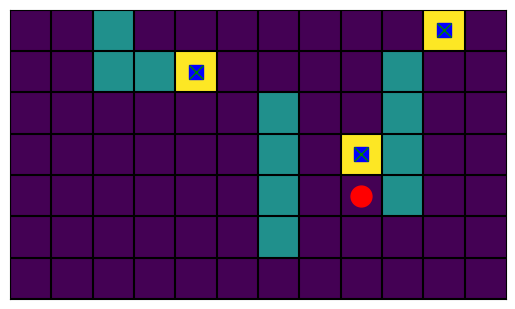


Testing super_hard_map1.yaml...
Solution found with 130 moves
States explored: 149
Pull moves used: 43
Time taken: 0.18 seconds
Initial state for super_hard_map1 


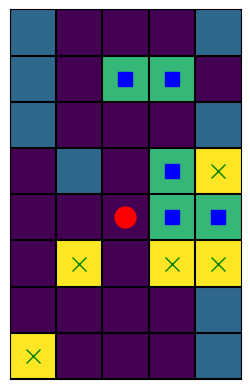

Solved state for super_hard_map1 


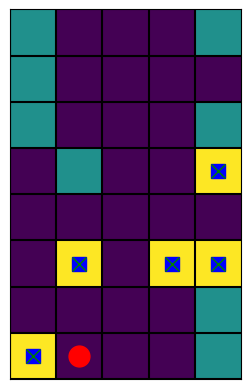

In [41]:

print("\n=== Testing LRTA* Algorithm ===")
algorithm_name = 'LRTA*'

for map_file in test_maps:
    import random
    random.seed()  # Ensure independent randomness for each run
    lrta_solver = LRTAStar(max_iterations=600000)  # New solver instance for each map
    print(f"\nTesting {os.path.basename(map_file)}...")
    result = solve_and_visualize(lrta_solver, map_file, algorithm_name)
    result['algorithm'] = algorithm_name
    result['map'] = os.path.basename(map_file)
    results.append(result)

# Test Simulated Annealing


=== Testing Simulated Annealing Algorithm ===

Testing easy_map1.yaml...
Solution found with 219 moves
States explored: 0
Pull moves used: 72
Time taken: 0.12 seconds
Initial state for easy_map1 


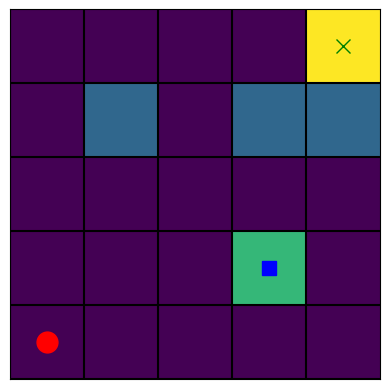

Solved state for easy_map1 


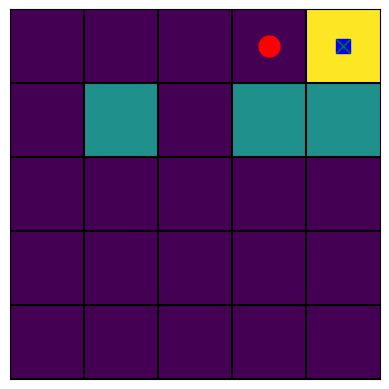


Testing easy_map2.yaml...
Solution found with 219 moves
States explored: 0
Pull moves used: 73
Time taken: 0.05 seconds
Initial state for easy_map2 


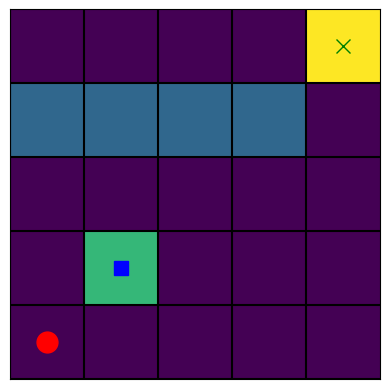

Solved state for easy_map2 


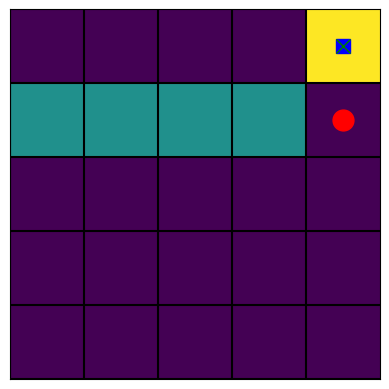


Testing medium_map1.yaml...
Solution found with 139 moves
States explored: 0
Pull moves used: 50
Time taken: 0.05 seconds
Initial state for medium_map1 


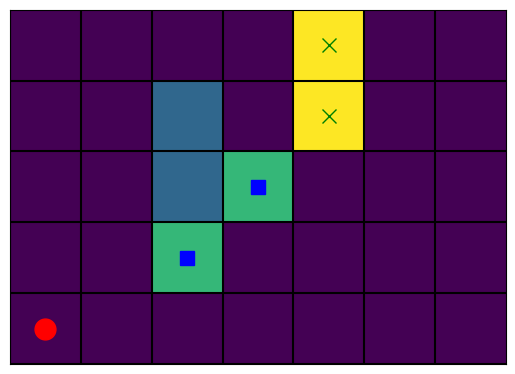

Solved state for medium_map1 


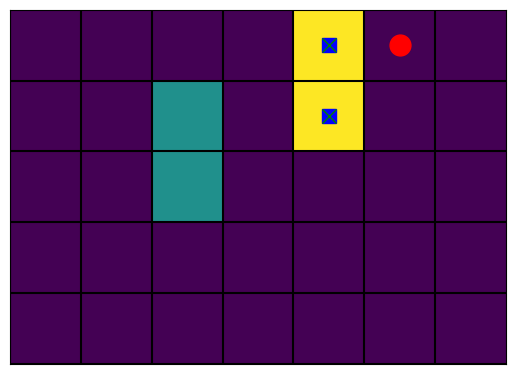


Testing medium_map2.yaml...
Solution found with 622 moves
States explored: 0
Pull moves used: 250
Time taken: 1.12 seconds
Initial state for medium_map2 


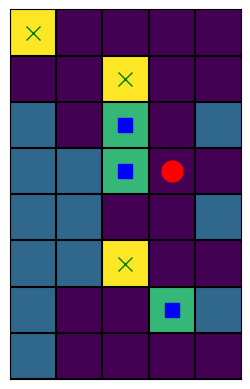

Solved state for medium_map2 


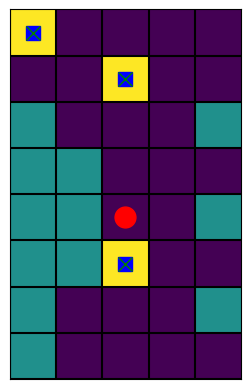


Testing hard_map1.yaml...
Solution found with 349 moves
States explored: 0
Pull moves used: 174
Time taken: 1.72 seconds
Initial state for hard_map1 


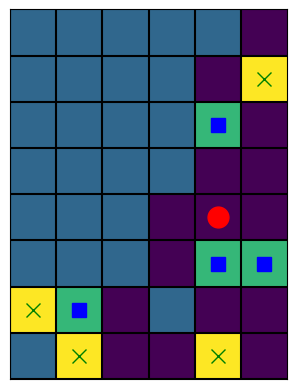

Solved state for hard_map1 


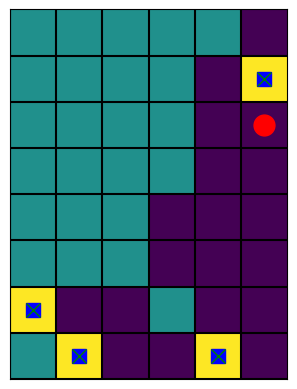


Testing hard_map2.yaml...
Solution found with 271 moves
States explored: 0
Pull moves used: 105
Time taken: 8.32 seconds
Initial state for hard_map2 


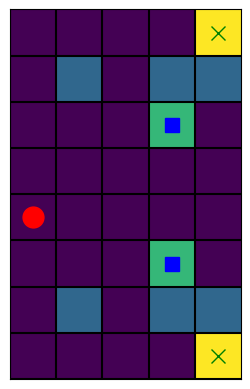

Solved state for hard_map2 


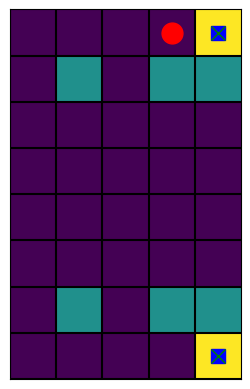


Testing large_map1.yaml...
Solution found with 622 moves
States explored: 0
Pull moves used: 212
Time taken: 1.65 seconds
Initial state for large_map1 


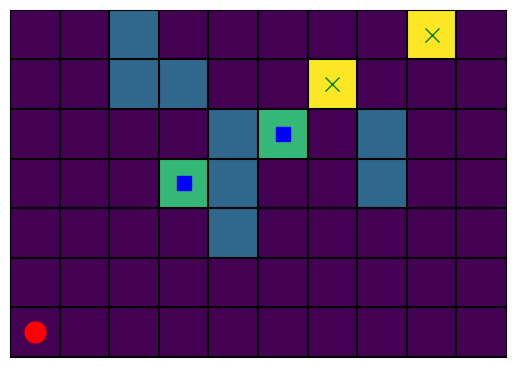

Solved state for large_map1 


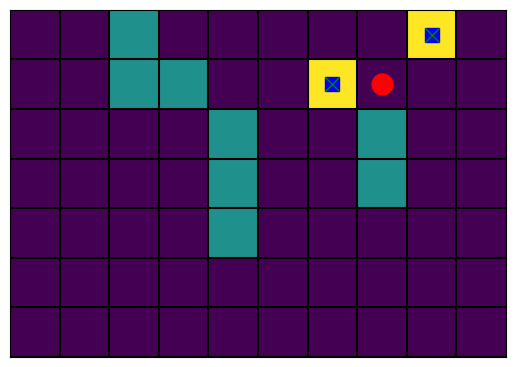


Testing large_map2.yaml...
Solution found with 970 moves
States explored: 0
Pull moves used: 290
Time taken: 3.59 seconds
Initial state for large_map2 


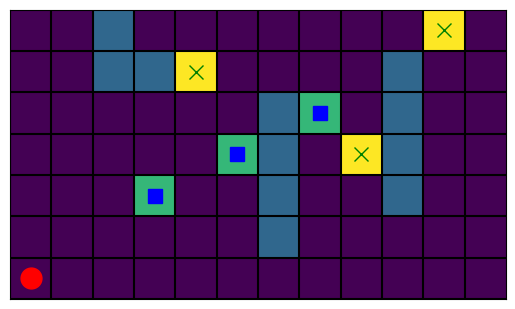

Solved state for large_map2 


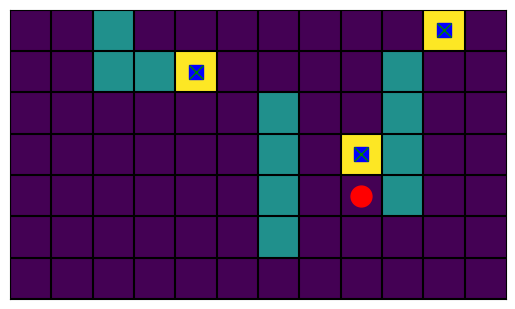


Testing super_hard_map1.yaml...
Solution found with 340 moves
States explored: 0
Pull moves used: 172
Time taken: 58.34 seconds
Initial state for super_hard_map1 


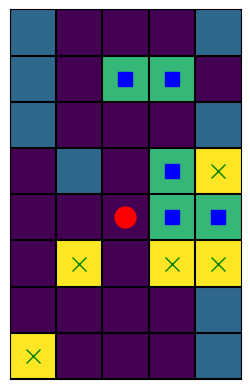

Solved state for super_hard_map1 


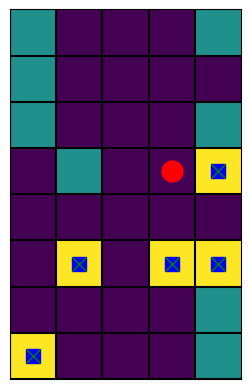

In [42]:
print("\n=== Testing Simulated Annealing Algorithm ===")
sa_solver = SimulatedAnnealing(
    initial_temp=100.0,
    cooling_rate=0.9999,
    min_temp=0.05,
    max_iterations=200000,
    restart_temp=50.0,
    plateau_limit=100,
)
algorithm_name = 'Simulated Annealing'

for map_file in test_maps:
    print(f"\nTesting {os.path.basename(map_file)}...")
    result = solve_and_visualize(sa_solver, map_file, algorithm_name)
    result['algorithm'] = algorithm_name
    result['map'] = os.path.basename(map_file)
    results.append(result)




# plot the comparisons

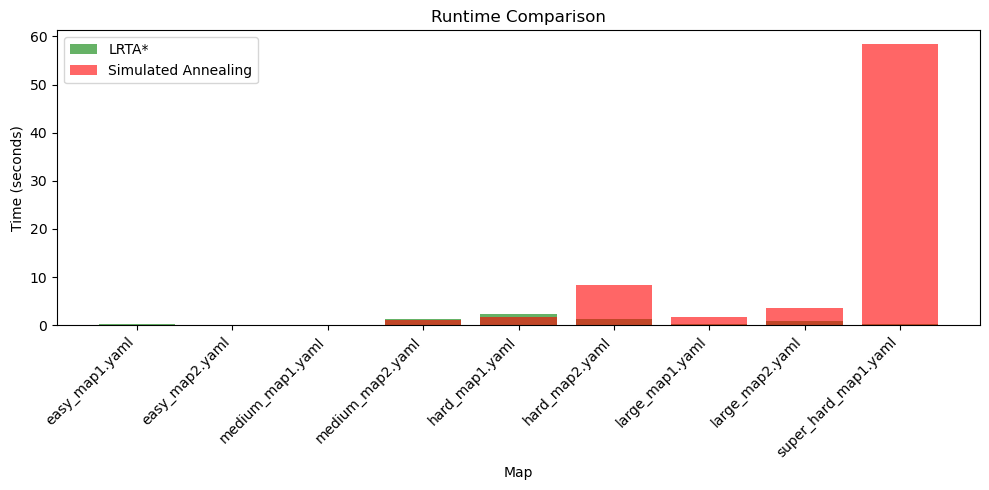

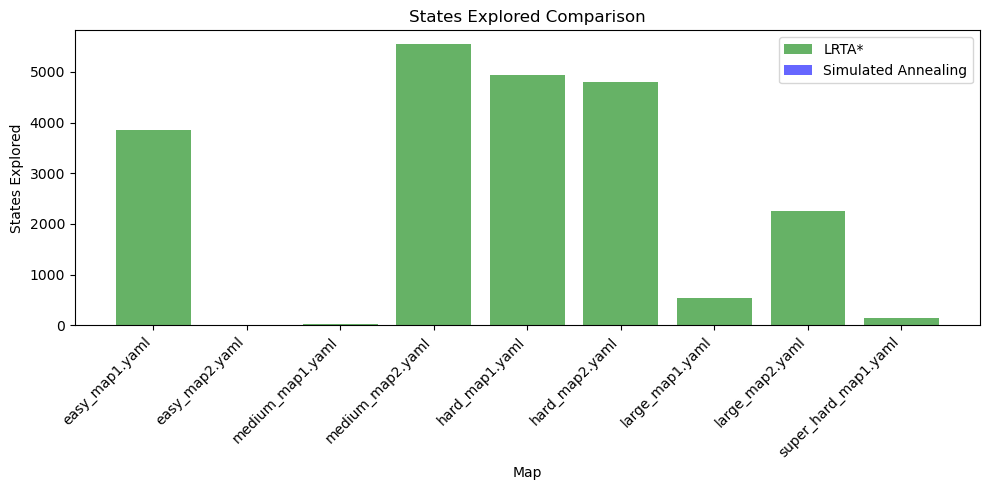

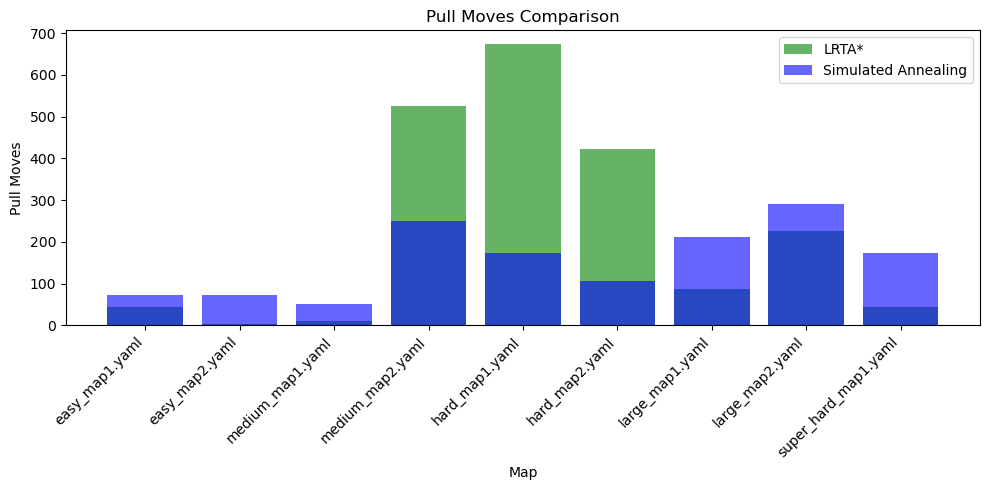

In [43]:
plot_comparisons(results)